# Assignment 1 - Social Data Analysis 2026
This notebook contains complete solutions for Assignment 1.

## 1. Environment Setup
We ensure all necessary libraries for Python 3.12.1 are installed.

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [22]:
# Install necessary libraries
%pip install pandas numpy matplotlib seaborn scipy ipykernel

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
focus_crimes = ['LARCENY THEFT', 'BURGLARY', 'DRUG OFFENSE', 'VEHICLE THEFT', 'ROBBERY', 'VANDALISM', 'ASSAULT', 'PROSTITUTION']


## 2. Data Acquisition
**Note**: The real datasets are ~1GB. We provide a **Mock Data generator** so you can see the visualizations immediately. Use the download cell below to get the real data.

In [24]:
def download_data():
    
    url_hist = "https://data.sfgov.org/api/views/tmnf-yvry/rows.csv?accessType=DOWNLOAD"
    url_recent = "https://data.sfgov.org/api/views/wg3w-h783/rows.csv?accessType=DOWNLOAD"
    
    if not os.path.exists('hist.csv'): 
        print("Downloading Historical Data (~500MB)...")
        urllib.request.urlretrieve(url_hist, 'hist.csv')
    if not os.path.exists('recent.csv'): 
        print("Downloading Recent Data (~500MB)...")
        urllib.request.urlretrieve(url_recent, 'recent.csv')
    print("Downloads complete or files already exist.")

# Uncomment the line below to download real data
download_data()

Downloads complete or files already exist.


In [25]:
def get_data():
    if os.path.exists('hist.csv') and os.path.exists('recent.csv'):
        print("Loading real data...")
        df_hist = pd.read_csv('hist.csv')
        df_recent = pd.read_csv('recent.csv')
        # Merging logic (as before)
        # Standardize categories
        df_hist['Category'] = df_hist['Category'].str.upper().str.replace('/', ' ')
        df_recent['Category'] = df_recent['Incident Category'].str.upper().str.replace('/', ' ')
        
        crime_map = {
            'DRUG NARCOTIC': 'DRUG OFFENSE', 
            'MOTOR VEHICLE THEFT': 'VEHICLE THEFT', 
            'LARCENY/THEFT': 'LARCENY THEFT'
        }
        df_hist['Category'] = df_hist['Category'].replace(crime_map)
        df_recent['Category'] = df_recent['Category'].replace(crime_map)
        h = df_hist[['Category', 'PdDistrict', 'Date', 'Time', 'X', 'Y']].copy()
        r = df_recent[['Category', 'Police District', 'Incident Date', 'Incident Time', 'Longitude', 'Latitude']].copy()
        r.columns = h.columns
        df = pd.concat([h, r], ignore_index=True)
        # Remove invalid coordinates and NaNs
        df = df.dropna(subset=['X', 'Y', 'Date', 'Time'])
        df = df[(df['X'] < -122.3) & (df['X'] > -122.6) & (df['Y'] < 37.9) & (df['Y'] > 37.6)]
        df['Date'] = pd.to_datetime(df['Date'], format='mixed')
        return df
    else:
        print("Real data not found. Generating Mock Data for visualization...")
        np.random.seed(42)
        n = 5000
        start_date = datetime(2003, 1, 1)
        dates = [start_date + timedelta(days=np.random.randint(0, 8000)) for _ in range(n)]
        df = pd.DataFrame({
            'Category': np.random.choice(focus_crimes, n),
            'PdDistrict': np.random.choice(['MISSION', 'TENDERLOIN', 'CENTRAL', 'SOUTHERN', 'BAYVIEW'], n),
            'Date': dates,
            'Time': [f"{np.random.randint(0, 24):02d}:{np.random.randint(0, 60):02d}:00" for _ in range(n)],
            'X': np.random.normal(-122.42, 0.02, n),
            'Y': np.random.normal(37.77, 0.02, n)
        })
        return df

df = get_data()

Loading real data...


C:\Users\FrederikSunesen\AppData\Local\Temp\ipykernel_20008\2760181415.py:5: DtypeWarning: Columns (0: Intersection, 1: Analysis Neighborhood, 2: Point) have mixed types. Specify dtype option on import or set low_memory=False.
  df_recent = pd.read_csv('recent.csv')


## 1.1: Temporal Overview

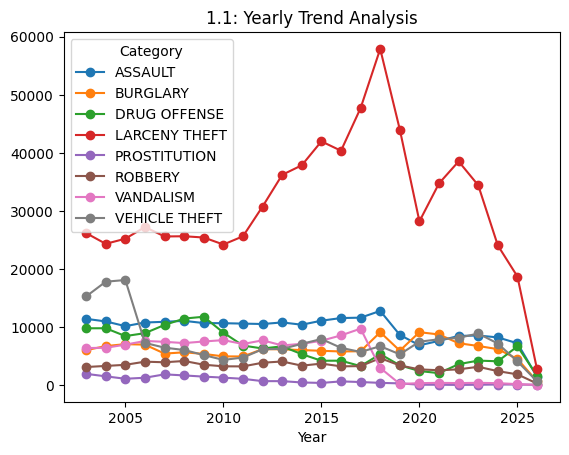

In [26]:
def exercise_1_1(df):
    df['Year'] = df['Date'].dt.year
    yearly = df[df['Category'].isin(focus_crimes)].groupby(['Year', 'Category']).size().unstack()
    yearly.plot(marker='o')
    plt.title("1.1: Yearly Trend Analysis")
    plt.show()

exercise_1_1(df)

## 1.2: Crime Profiles by Police District

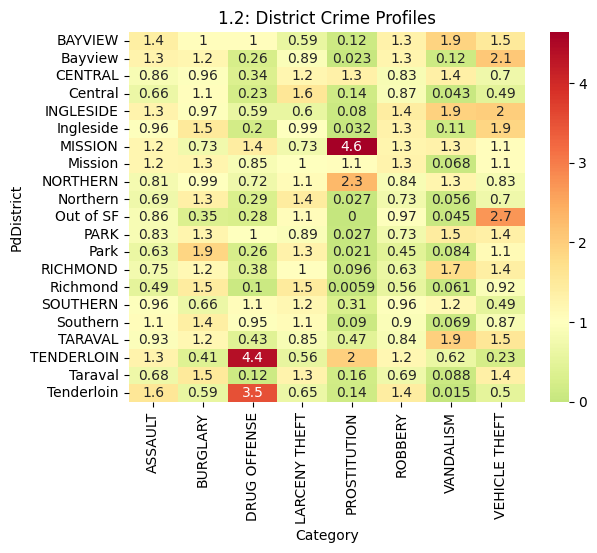

In [27]:
def exercise_1_2(df):
    focus_df = df[df['Category'].isin(focus_crimes)]
    ct = pd.crosstab(focus_df['PdDistrict'], focus_df['Category'])
    ratios = (ct.div(ct.sum(axis=1), axis=0)) / (ct.sum(axis=0) / ct.values.sum())
    sns.heatmap(ratios, cmap='RdYlGn_r', center=1, annot=True)
    plt.title("1.2: District Crime Profiles")
    plt.show()

exercise_1_2(df)

## 1.3: Visualizing Distributions

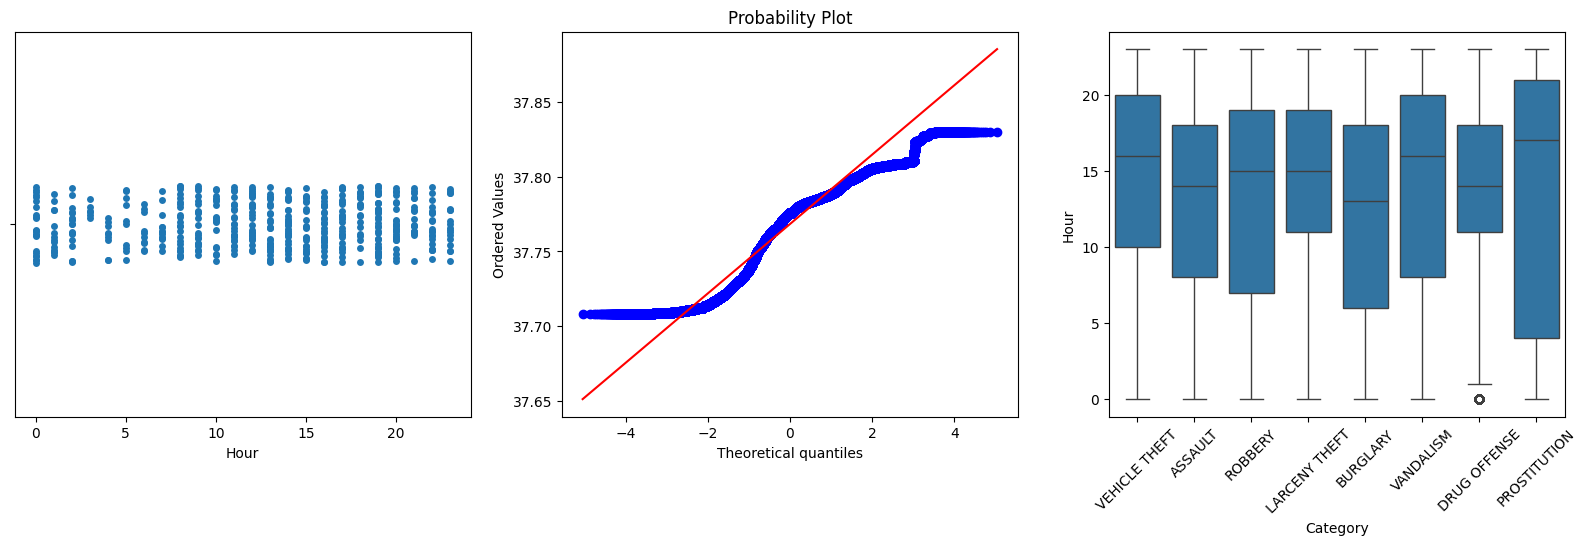

In [28]:
def exercise_1_3(df):
    df['Hour'] = pd.to_datetime(df['Time'], format='mixed').dt.hour
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    sns.stripplot(data=df.sample(500), x='Hour', jitter=True, ax=axes[0])
    stats.probplot(df['Y'], dist="norm", plot=axes[1])
    sns.boxplot(data=df[df['Category'].isin(focus_crimes)], x='Category', y='Hour', ax=axes[2])
    plt.setp(axes[2].get_xticklabels(), rotation=45)
    plt.show()

exercise_1_3(df)

## 1.4: Spatial Power Law

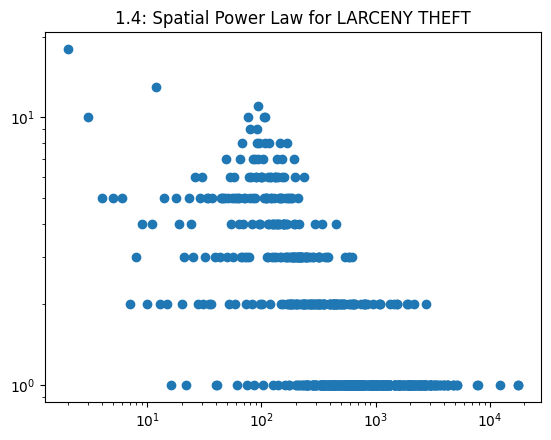

In [29]:
def exercise_1_4(df):
    crime = focus_crimes[0]
    data = df[df['Category'] == crime]
    H, _, _ = np.histogram2d(data['X'], data['Y'], bins=50)
    counts = H.flatten(); counts = counts[counts > 0]
    u, f = np.unique(counts, return_counts=True)
    plt.loglog(u+1, f, 'o')
    plt.title(f"1.4: Spatial Power Law for {crime}")
    plt.show()

exercise_1_4(df)

## 1.5: Regression and Correlation

In [30]:
def manual_regression(x, y):
    a = (np.sum(x*y) - len(x)*np.mean(x)*np.mean(y)) / (np.sum(x**2) - len(x)*np.mean(x)**2)
    b = np.mean(y) - a * np.mean(x)
    return a, b

print("Regression formula ready.")

Regression formula ready.
